=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


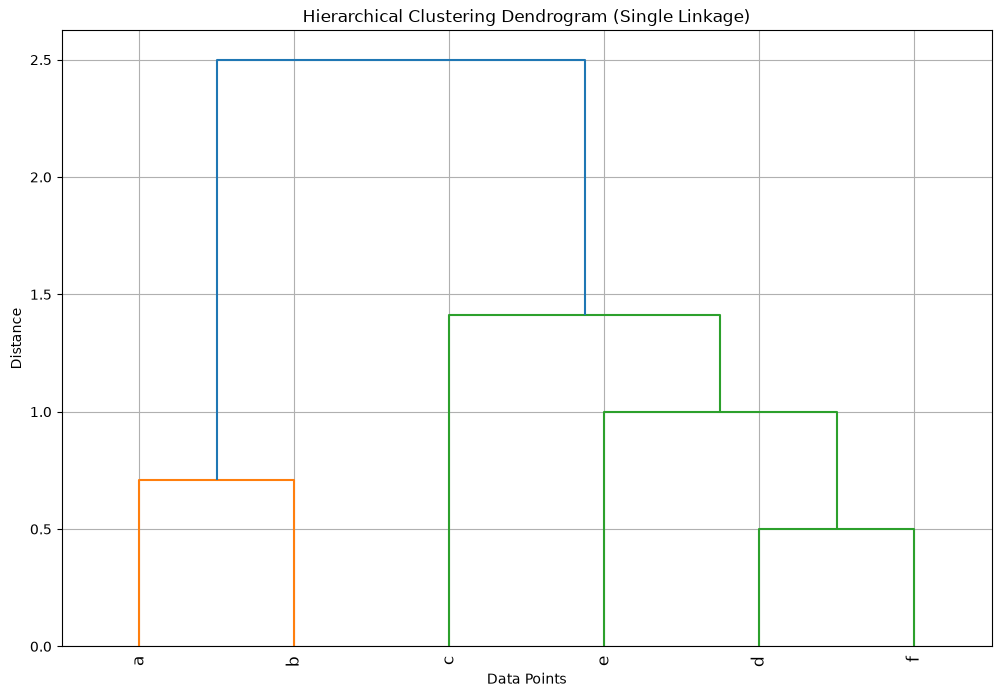

In [7]:
# IMPORT LIBRARY
import numpy as np  # Mengelola array numerik dan operasi matriks
import pandas as pd  # Membuat tabel (DataFrame) agar matriks jarak mudah dibaca
from scipy.cluster.hierarchy import (
    dendrogram,
    linkage,
)  # Fungsi klastering hierarki dan visualisasi pohon (dendrogram)
from scipy.spatial.distance import (
    pdist,
    squareform,
)  # pdist: hitung jarak antar titik; squareform: ubah hasil ke matriks persegi
import matplotlib.pyplot as plt  # Membuat plot dan menampilkan grafik

# 1. DEFINISI DATASET
# Titik koordinat 2D untuk 6 sampel data (a, b, c, d, e, f)
data = np.array(
    [
        [1.0, 1.0],  # a
        [1.5, 1.5],  # b
        [5.0, 5.0],  # c
        [3.0, 4.0],  # d
        [4.0, 4.0],  # e
        [3.0, 3.5],  # f
    ]
)

# 2. PERHITUNGAN DISTANCE MATRIX
# Menghitung jarak lurus antar tiap pasangan titik menggunakan rumus Euclidean
distance_matrix = pdist(data, metric="euclidean")

# Mengubah vektor jarak 1D menjadi matriks simetris 2D berlabel baris & kolom
distance_df = pd.DataFrame(
    squareform(distance_matrix),
    columns=["a", "b", "c", "d", "e", "f"],
    index=["a", "b", "c", "d", "e", "f"],
)

# 3. MENAMPILKAN MATRIKS JARAK
# Mencetak tabel jarak untuk melihat kedekatan antar titik secara eksplisit
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

# 4. HIERARCHICAL CLUSTERING (SINGLE LINKAGE)
# Menggabungkan klaster secara bertahap berdasarkan jarak minimum (terdekat) antar anggota klaster
linked = linkage(data, method="single")

# 5. VISUALISASI DENDROGRAM
plt.figure(figsize=(12, 8))  # Mengatur ukuran kanvas plot
plt.title(
    "Hierarchical Clustering Dendrogram (Single Linkage)"
)  # Menambahkan judul grafik

# Menggambar diagram pohon hierarki dengan label data di sumbu X diputar 90 derajat
dendrogram(linked, labels=["a", "b", "c", "d", "e", "f"], leaf_rotation=90)

plt.xlabel("Data Points")  # Label sumbu X: titik data
plt.ylabel("Distance")  # Label sumbu Y: tingkat jarak penggabungan klaster
plt.grid(True)  # Menampilkan garis kisi untuk mempermudah membaca nilai jarak
plt.show()  # Menampilkan plot ke layar


---

#### 1. `pdist` dan `squareform`
* **`pdist`**: Menghasilkan jarak antar kombinasi pasangan titik dalam bentuk array 1-dimensi.
* **`squareform`**: Mengonversinya menjadi matriks simetris berukuran $6 \times 6$, di mana diagonal utamanya bernilai $0$ (jarak titik ke dirinya sendiri).

#### 2. `method='single'`
* Menggunakan aturan **Single Linkage** (jarak minimum antar anggota terdekat dari dua klaster).
* Titik-titik dengan jarak paling kecil (misalnya titik $a$ dan $b$, atau $d$ dan $f$) akan digabungkan terlebih dahulu di bagian bawah dendrogram.

#### 3. Tinggi Cabang Dendrogram
* **Sumbu $Y$**: Merepresentasikan nilai jarak ketika dua klaster digabungkan.
* **Interpretasi**: Semakin tinggi garis horizontal penghubung, semakin jauh jarak antar kelompok/titik yang disatukan.

### Penjelasan Kode dan Alur Eksekusi

Program ini diawali dengan mengimpor modul `numpy` untuk manipulasi array numerik, `pandas` untuk menyusun matriks jarak ke dalam bentuk tabel yang mudah dibaca, modul `scipy` untuk proses pengelompokan hierarki serta perhitungan jarak spasial, dan `matplotlib.pyplot` untuk kebutuhan visualisasi grafik.

Tahap berikutnya adalah mendefinisikan dataset berupa koordinat dua dimensi untuk enam titik data sampel, yaitu titik `a` sampai `f`. Setelah data siap, program menghitung jarak Euclidean antar setiap pasangan titik menggunakan fungsi `pdist`. Hasil perhitungan jarak yang awalnya berupa array satu dimensi ini kemudian dikonversi oleh fungsi `squareform` menjadi matriks simetris berukuran $6 \times 6$, di mana seluruh elemen diagonal utamanya bernilai $0$ karena merepresentasikan jarak titik terhadap dirinya sendiri[cite: 2]. Matriks ini selanjutnya dibungkus ke dalam DataFrame pandas berlabel agar nilai kedekatan antartitik dapat dicetak dan dibaca dengan jelas.

Pada tahap klastering, fungsi `linkage` dipanggil dengan parameter `method='single'`, yang berarti algoritma menerapkan aturan *Single Linkage* berdasarkan jarak minimum antaranggota terdekat dari dua klaster[cite: 2]. Melalui metode ini, titik-titik dengan nilai jarak paling kecil, seperti pasangan `a` dan `b` atau `d` dan `f`, akan diprioritaskan untuk digabungkan terlebih dahulu di bagian dasar hierarki[cite: 2].

Alur program ditutup dengan merender visualisasi dendrogram berukuran $12 \times 8$ menggunakan fungsi `dendrogram`. Pada grafik ini, sumbu $X$ menampilkan label tiap titik data yang diputar 90 derajat agar tidak saling tumpang tindih, sedangkan sumbu $Y$ menunjukkan nilai jarak saat dua kelompok digabungkan[cite: 2]. Semakin tinggi posisi cabang horizontal yang terbentuk, semakin besar jarak pemisah antara klaster-klaster yang disatukan[cite: 2]. Tampilan grafik juga dilengkapi dengan kisi bantu (*grid*) untuk mempermudah pembacaan nilai jarak secara visual.

---

In [ ]:
import pandas as pd  # Mengimpor pustaka Pandas untuk manipulasi dan analisis data berbentuk tabel (DataFrame)
# Membaca file dataset CSV dari direktori Google Colab ke dalam DataFrame
df = pd.read_csv("/content/Mall_Customers.csv")
# Menampilkan 5 baris pertama dataset untuk memeriksa struktur awal data dan kolom yang ada
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Pemuatan Data dan Eksplorasi Awal Dataset

Kode ini diawali dengan mengimpor modul `pandas` untuk kebutuhan manipulasi serta analisis data berbasis tabel atau DataFrame[cite: 3]. Selanjutnya, fungsi `pd.read_csv()` digunakan untuk membaca file dataset `Mall_Customers.csv` dari direktori penyimpanan Google Colab lalu menyimpannya ke dalam variabel `df`[cite: 3]. Tahapan ini diakhiri dengan pemanggilan metode `df.head()` untuk menampilkan lima baris teratas data[cite: 3], yang bertujuan memeriksa struktur awal tabel, memastikan seluruh kolom—seperti `CustomerID`, `Genre`, `Age`, `Annual Income (k$)`, dan `Spending Score (1-100)`—termuat dengan benar[cite: 3], serta melihat gambaran sekilas nilai amatan sebelum diproses lebih lanjut.

In [ ]:
# Mengambil seluruh baris (:) dan hanya kolom pada indeks 3 dan 4,
# lalu mengubahnya menjadi NumPy array (.values) untuk fitur pemodelan clustering
x = df.iloc[:, [3, 4]].values

### Ekstraksi Fitur untuk Pemodelan Klastering

Baris kode ini bertugas memilih variabel atau fitur numerik spesifik dari DataFrame `df` yang akan digunakan dalam proses pemodelan klastering[cite: 4]. Melalui fungsi `iloc[:, [3, 4]]`, program mengambil seluruh baris data menggunakan simbol titik dua (`:`) dan hanya menyaring kolom pada indeks ke-3 (`Annual Income (k$)`) serta indeks ke-4 (`Spending Score (1-100)`)[cite: 3, 4]. Penambahan atribut `.values` di akhir perintah berfungsi mengonversi irisan data tersebut dari format DataFrame Pandas menjadi array NumPy dua dimensi yang disimpan ke dalam variabel `x`[cite: 4], format standar yang siap diolah oleh algoritma klastering.

In [ ]:
from sklearn.preprocessing import (
    StandardScaler,
)  # Mengimpor modul untuk standarisasi fitur (Z-score normalization)

# Inisialisasi objek scaler dengan rata-rata = 0 dan varians = 1
data_scaler = StandardScaler()

# Menghitung mean & standar deviasi (fit), lalu mentransformasi data x ke skala standar
scaled_data = data_scaler.fit_transform(x)

# Memeriksa dimensi array data hasil transformasi (jumlah baris, jumlah kolom)
scaled_data.shape

(200, 2)

### Ekstraksi Fitur untuk Pemodelan Klastering

Baris kode ini bertugas memilih variabel atau fitur numerik spesifik dari DataFrame `df` yang akan digunakan dalam proses pemodelan klastering[cite: 4]. Melalui fungsi `iloc[:, [3, 4]]`, program mengambil seluruh baris data menggunakan simbol titik dua (`:`) dan hanya menyaring kolom pada indeks ke-3 (`Annual Income (k$)`) serta indeks ke-4 (`Spending Score (1-100)`)[cite: 3, 4]. Penambahan atribut `.values` di akhir perintah berfungsi mengonversi irisan data tersebut dari format DataFrame Pandas menjadi array NumPy dua dimensi yang disimpan ke dalam variabel `x`[cite: 4], format standar yang siap diolah oleh algoritma klastering.

In [ ]:
from scipy.cluster.hierarchy import (
    dendrogram,
    linkage,
)  # Mengimpor modul untuk hierarchical clustering dan visualisasi dendrogram

# Melakukan hierarchical clustering secara agglomerative (bottom-up)
# Menggunakan Complete Linkage (jarak maksimum antar anggota klaster) dan Euclidean Distance
clustering = linkage(scaled_data, method="complete", metric="euclidean")

### Pembentukan Klaster Hierarki Menggunakan Complete Linkage

Tahap ini diawali dengan mengimpor modul `dendrogram` dan `linkage` dari pustaka `scipy.cluster.hierarchy` untuk keperluan analisis pengelompokan hierarki serta visualisasi pohon klaster[cite: 6]. Pemodelan dilakukan secara *agglomerative* (pendekatan *bottom-up*) menggunakan fungsi `linkage()` terhadap data yang telah distandarisasi (`scaled_data`)[cite: 6]. 

Pada proses ini, parameter `method='complete'` ditetapkan untuk menerapkan metode *Complete Linkage*, yaitu penentuan jarak antarklaster berdasarkan jarak terjauh (maksimum) antara dua titik pada masing-masing klaster[cite: 6]. Selain itu, parameter `metric='euclidean'` digunakan sebagai rumus dasar pengukuran jarak geometris antartitik[cite: 6]. Hasil proses hierarki ini disimpan ke dalam variabel `clustering`[cite: 6], yang memuat struktur penggabungan klaster bertahap dan siap divisualisasikan menjadi dendrogram.

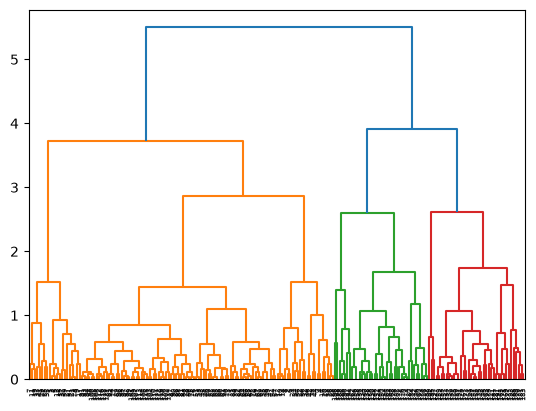

In [ ]:
import matplotlib.pyplot as plt  # Mengimpor modul visualisasi grafik dari pustaka Matplotlib

# Menggambar diagram pohon hierarki klaster berdasarkan matriks linkage yang sudah dihitung
dendrogram(clustering)

# Menampilkan grafik dendrogram ke layar / output cell notebook
plt.show()

### Visualisasi dan Interpretasi Dendrogram (Complete Linkage)

Tahap visualisasi ini dilakukan dengan memanfaatkan modul `matplotlib.pyplot` untuk merender struktur pohon klaster yang sebelumnya telah dibentuk oleh fungsi `linkage()`[cite: 7]. Melalui pemanggilan fungsi `dendrogram(clustering)`, hubungan hierarki antardata dipetakan secara grafis, lalu ditampilkan ke layar menggunakan perintah `plt.show()`[cite: 7]. 

Hasil grafik dendrogram memperlihatkan proses penggabungan bertahap dari 200 sampel data konsumen mulai dari tingkat individu di bagian bawah hingga bersatu menjadi satu kesatuan klaster di bagian atas[cite: 5, 8]. Sumbu vertikal ($Y$) menunjukkan tingkat jarak atau ketidaksamaan antarkelompok saat disatukan, di mana garis horizontal penghubung tertinggi berada di atas nilai jarak 5[cite: 8]. Pengelompokan ini ditandai dengan warna cabang yang berbeda (oranye, hijau, dan merah) yang mencerminkan pemisahan klaster utama pada ambang batas jarak tertentu[cite: 8], sehingga memudahkan penentuan jumlah klaster optimal yang paling representatif untuk segmentasi data pelanggan.

### Analisis Komparasi Dendrogram: Single, Complete, dan Average Linkage

Berdasarkan hasil plot dendrogram pada dataset sederhana enam titik data ($a$ hingga $f$), terlihat perbedaan karakteristik penggabungan klaster yang signifikan dari ketiga metode linkage:

* **Single Linkage (Jarak Minimum)**:
  Penggabungan klaster didasarkan pada jarak terpendek antaranggota terdekat dari dua kelompok[cite: 2]. Karakteristik ini membuat tinggi cabang horizontal pada sumbu $Y$ cenderung paling rendah dibandingkan metode lainnya, karena klaster dapat bergabung dengan cepat meskipun sebagian besar anggotanya berada jauh (*chaining effect*). Pasangan titik dengan kedekatan ekstrem, seperti $a$ dan $b$ atau $d$ dan $f$, menjadi fondasi awal penggabungan di bagian dasar dendrogram[cite: 2].

* **Complete Linkage (Jarak Maksimum)**:
  Penggabungan klaster ditentukan oleh jarak terjauh antaranggota dari dua kelompok[cite: 6]. Akibatnya, nilai jarak pada sumbu $Y$ saat klaster disatukan berada pada posisi yang jauh lebih tinggi. Metode ini menghasilkan klaster yang lebih kompak, seragam, dan memiliki batas pemisah antarkelompok yang jauh lebih tegas karena memerlukan seluruh anggota klaster berada dalam radius jarak yang relatif dekat sebelum disatukan.

* **Average Linkage (Jarak Rata-rata)**:
  Penggabungan klaster menggunakan nilai rata-rata dari seluruh jarak kombinasi pasangan titik antarkelompok. Pola tinggi cabang dendrogram berada di posisi tengah (moderat) antara *single linkage* dan *complete linkage*. Metode ini memberikan representasi struktur kelompok yang lebih seimbang, tidak terlalu sensitif terhadap rantai data memanjang seperti *single linkage*, dan tidak terlalu ketat memaksakan bentuk klaster bulat/kompak seperti *complete linkage*.

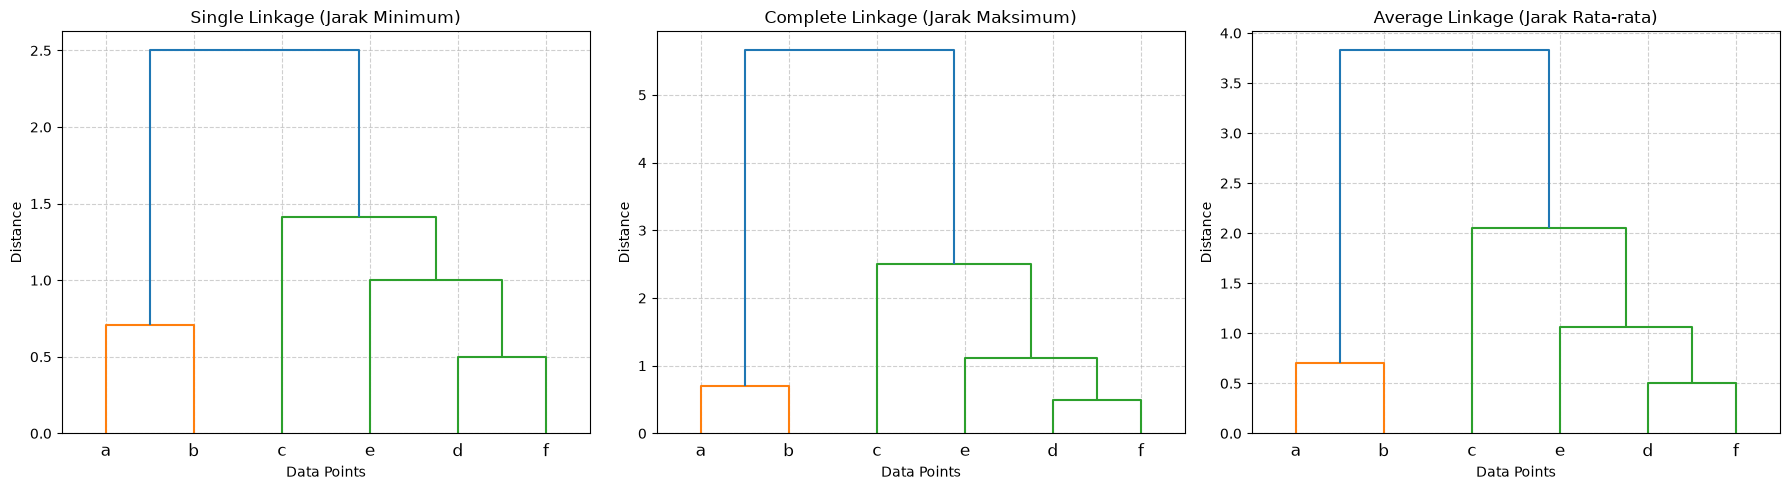

In [ ]:
# TUGAS
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage

# Dataset sederhana dari percobaan pertama
data = np.array(
    [
        [1.0, 1.0],  # a
        [1.5, 1.5],  # b
        [5.0, 5.0],  # c
        [3.0, 4.0],  # d
        [4.0, 4.0],  # e
        [3.0, 3.5],  # f
    ]
)

labels = ["a", "b", "c", "d", "e", "f"]

# 1. Menghitung Hierarchical Clustering untuk ketiga metode
linked_single = linkage(data, method="single", metric="euclidean")
linked_complete = linkage(data, method="complete", metric="euclidean")
linked_average = linkage(data, method="average", metric="euclidean")

# 2. Menampilkan ketiga dendrogram secara berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Single Linkage
dendrogram(linked_single, labels=labels, ax=axes[0], leaf_rotation=0)
axes[0].set_title("Single Linkage (Jarak Minimum)")
axes[0].set_xlabel("Data Points")
axes[0].set_ylabel("Distance")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot Complete Linkage
dendrogram(linked_complete, labels=labels, ax=axes[1], leaf_rotation=0)
axes[1].set_title("Complete Linkage (Jarak Maksimum)")
axes[1].set_xlabel("Data Points")
axes[1].set_ylabel("Distance")
axes[1].grid(True, linestyle="--", alpha=0.6)

# Plot Average Linkage
dendrogram(linked_average, labels=labels, ax=axes[2], leaf_rotation=0)
axes[2].set_title("Average Linkage (Jarak Rata-rata)")
axes[2].set_xlabel("Data Points")
axes[2].set_ylabel("Distance")
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### Perbandingan Visualisasi Klastering Hierarki: Single, Complete, dan Average Linkage

Kode ini bertujuan membandingkan secara langsung karakteristik penggabungan klaster pada dataset enam titik sampel (`a` hingga `f`) menggunakan tiga metode linkage yang berbeda: *Single Linkage*, *Complete Linkage*, dan *Average Linkage*.

Proses perhitungan dilakukan menggunakan fungsi `linkage()` dengan metrik jarak Euclidean, di mana variabel `linked_single` menghitung kedekatan berbasis jarak minimum antarpasangan terdekat, `linked_complete` menggunakan jarak maksimum antaranggota terjauh, dan `linked_average` menentukan penggabungan berdasarkan rata-rata jarak seluruh anggota antarklaster. Untuk menyajikan perbandingan secara efektif, fungsi `plt.subplots(1, 3, figsize=(18, 5))` membuat kanvas visualisasi dengan tiga kolom berdampingan. Setiap subplot kemudian diisi fungsi `dendrogram()` yang dipetakan ke sumbunya masing-masing (`ax=axes[0]`, `ax=axes[1]`, dan `ax=axes[2]`), lengkap dengan label titik pada posisi mendatar, judul metode, penamaan sumbu, serta garis bantu (*grid*).

Hasil visualisasi berdampingan ini memperlihatkan perbedaan struktur pohon hierarki yang dihasilkan oleh masing-masing pendekatan. *Single Linkage* cenderung membentuk efek rantai (*chaining effect*) dengan tinggi cabang yang lebih rendah karena hanya memperhitungkan jarak minimum. Sebaliknya, *Complete Linkage* menghasilkan cabang horizontal yang jauh lebih tinggi pada level atas akibat penggunaan jarak maksimum, sehingga memicu pembentukan klaster yang lebih padat dan terpisah tegas. Sementara itu, *Average Linkage* memberikan hasil kompromi yang seimbang di antara keduanya, menunjukkan struktur hierarki yang lebih stabil terhadap keberadaan data pencilan (*outliers*).